Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original dataset shape: (569, 33)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414  

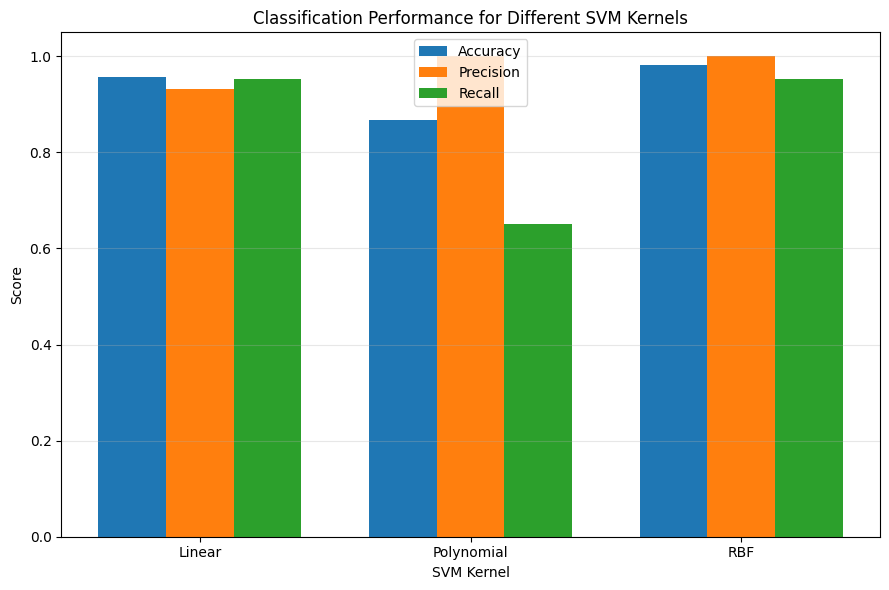


               BEST SVM MODEL

Best Kernel: RBF
Accuracy : 0.9825
Precision: 1.0000
Recall   : 0.9535

      BEST SVM VS LOGISTIC REGRESSION

              Model  Accuracy  Precision  Recall
          SVM (RBF)    0.9825     1.0000  0.9535
Logistic Regression    0.9825     1.0000  0.9524


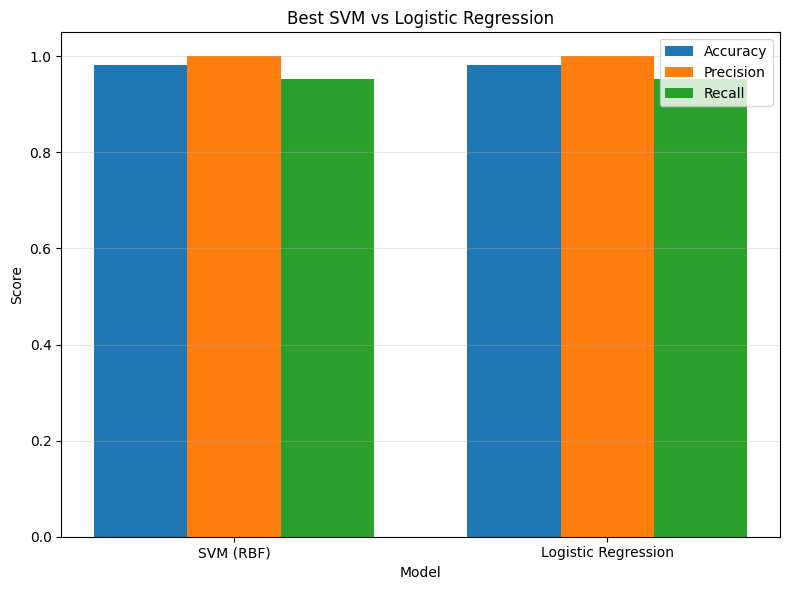

In [3]:
# ============================================================
# Homework 4 - Problem 1
# SVM Classification of Breast Cancer
# ============================================================


# ------------------------------------------------------------
# 1. Import Libraries
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score
)


# ------------------------------------------------------------
# 2. Mount Google Drive
# ------------------------------------------------------------

drive.mount('/content/drive')


# ------------------------------------------------------------
# 3. Load Cancer Dataset
# ------------------------------------------------------------

# Change the path if Cancer.csv is stored in another folder
data = pd.read_csv('/content/drive/MyDrive/Cancer.csv')

print("Original dataset shape:", data.shape)
print(data.head())


# ------------------------------------------------------------
# 4. Clean Dataset
# ------------------------------------------------------------

# Remove patient ID because it is not an input feature
data = data.drop(columns=['id'])

# Remove the empty column
if 'Unnamed: 32' in data.columns:
    data = data.drop(columns=['Unnamed: 32'])

# Convert diagnosis to binary values
# Malignant = 1
# Benign = 0
data['diagnosis'] = data['diagnosis'].map({
    'M': 1,
    'B': 0
})


# ------------------------------------------------------------
# 5. Separate Features and Target
# ------------------------------------------------------------

X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

print("\nNumber of samples:", X.shape[0])
print("Number of input features:", X.shape[1])

print("\nClass distribution:")
print(y.value_counts())


# ------------------------------------------------------------
# 6. Split Dataset
#    80% Training / 20% Testing
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# ------------------------------------------------------------
# 7. Standardize Features
# ------------------------------------------------------------

scaler = StandardScaler()

# Learn scaling parameters from the training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to the test data
X_test_scaled = scaler.transform(X_test)


# ------------------------------------------------------------
# 8. Define SVM Models with Different Kernels
# ------------------------------------------------------------

svm_models = {
    'Linear': SVC(kernel='linear'),
    'Polynomial': SVC(kernel='poly'),
    'RBF': SVC(kernel='rbf')
}


# ------------------------------------------------------------
# 9. Train and Evaluate Each SVM
# ------------------------------------------------------------

results = []

for kernel_name, model in svm_models.items():

    # Train the model
    model.fit(X_train_scaled, y_train)

    # Predict test samples
    y_pred = model.predict(X_test_scaled)

    # Calculate performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    # Store results
    results.append([
        kernel_name,
        accuracy,
        precision,
        recall
    ])


# ------------------------------------------------------------
# 10. Create Results Table
# ------------------------------------------------------------

results_df = pd.DataFrame(
    results,
    columns=[
        'Kernel',
        'Accuracy',
        'Precision',
        'Recall'
    ]
)

print("\n==============================================")
print("            SVM KERNEL RESULTS")
print("==============================================\n")

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f'{x:.4f}'
    )
)


# ============================================================
# FIGURE 1
# Classification Performance of Different SVM Kernels
# ============================================================

x = np.arange(len(results_df))
width = 0.25

plt.figure(figsize=(9, 6))

plt.bar(
    x - width,
    results_df['Accuracy'],
    width,
    label='Accuracy'
)

plt.bar(
    x,
    results_df['Precision'],
    width,
    label='Precision'
)

plt.bar(
    x + width,
    results_df['Recall'],
    width,
    label='Recall'
)

plt.xlabel('SVM Kernel')
plt.ylabel('Score')

plt.title(
    'Classification Performance for Different SVM Kernels'
)

plt.xticks(
    x,
    results_df['Kernel']
)

plt.ylim(0, 1.05)

plt.legend()

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. Find Best SVM Kernel Based on Accuracy
# ------------------------------------------------------------

best_index = results_df['Accuracy'].idxmax()

best_kernel = results_df.loc[
    best_index,
    'Kernel'
]

best_accuracy = results_df.loc[
    best_index,
    'Accuracy'
]

best_precision = results_df.loc[
    best_index,
    'Precision'
]

best_recall = results_df.loc[
    best_index,
    'Recall'
]


print("\n==============================================")
print("               BEST SVM MODEL")
print("==============================================\n")

print("Best Kernel:", best_kernel)
print(f"Accuracy : {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall   : {best_recall:.4f}")


# ============================================================
# 12. Homework 3 Logistic Regression Results
# ============================================================
#
# These are the results obtained previously in Homework 3
# using the same cancer dataset.
#
# Accuracy  = 0.9825
# Precision = 1.0000
# Recall    = 0.9524
#
# ------------------------------------------------------------

logistic_accuracy = 0.9825
logistic_precision = 1.0000
logistic_recall = 0.9524


# ------------------------------------------------------------
# 13. Create Comparison Table
# ------------------------------------------------------------

comparison_df = pd.DataFrame({

    'Model': [
        f'SVM ({best_kernel})',
        'Logistic Regression'
    ],

    'Accuracy': [
        best_accuracy,
        logistic_accuracy
    ],

    'Precision': [
        best_precision,
        logistic_precision
    ],

    'Recall': [
        best_recall,
        logistic_recall
    ]
})


print("\n==============================================")
print("      BEST SVM VS LOGISTIC REGRESSION")
print("==============================================\n")

print(
    comparison_df.to_string(
        index=False,
        float_format=lambda x: f'{x:.4f}'
    )
)


# ============================================================
# FIGURE 2
# Best SVM vs Logistic Regression from Homework 3
# ============================================================

x = np.arange(len(comparison_df))
width = 0.25

plt.figure(figsize=(8, 6))

plt.bar(
    x - width,
    comparison_df['Accuracy'],
    width,
    label='Accuracy'
)

plt.bar(
    x,
    comparison_df['Precision'],
    width,
    label='Precision'
)

plt.bar(
    x + width,
    comparison_df['Recall'],
    width,
    label='Recall'
)

plt.xlabel('Model')
plt.ylabel('Score')

plt.title(
    'Best SVM vs Logistic Regression'
)

plt.xticks(
    x,
    comparison_df['Model']
)

plt.ylim(0, 1.05)

plt.legend()

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()
plt.show()